# Project - Ethics of AI
## | Make Ethical a Classic AI Workflow |

---

## Downloading

In [30]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import random
from scipy.stats import chi2_contingency


---

## Data Ingestion

### Import

In [31]:
df_init = pd.read_csv("../data/Loan.csv")
random.seed(7)

### Cleaning

In [32]:
df_init_proper = df_init[
    [
        "Age", 
        "MaritalStatus", 
        "EmploymentStatus", 
        "EducationLevel", 
        "Experience", 
        "MonthlyLoanPayment", 
        "MonthlyIncome", 
        "UtilityBillsPaymentHistory",
        "LoanApproved"
    ]
]

### Exploration

In [33]:
display(df_init_proper)
print(df_init_proper.dtypes)

,Age,MaritalStatus,EmploymentStatus,EducationLevel,Experience,MonthlyLoanPayment,MonthlyIncome,UtilityBillsPaymentHistory,LoanApproved
0,45,Married,Employed,Master,22,419.805992,3329.000000,0.724972,0
1,38,Single,Employed,Associate,15,794.054238,3309.083333,0.935132,0
2,47,Married,Employed,Bachelor,26,666.406688,3393.666667,0.872241,0
3,58,Single,Employed,High School,34,1047.506980,5757.000000,0.896155,0
4,37,Married,Employed,Associate,17,330.179140,8605.333333,0.941369,1
...,...,...,...,...,...,...,...,...,...
19995,44,Married,Employed,High School,19,905.767712,2515.000000,0.826217,0
19996,56,Married,Employed,Associate,33,958.395633,4103.833333,0.816618,0
19997,44,Married,Employed,Bachelor,20,945.427454,4079.833333,0.887216,0
19998,60,Married,Employed,High School,36,411.168284,3418.750000,0.843787,0


Age                             int64
MaritalStatus                  object
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
MonthlyLoanPayment            float64
MonthlyIncome                 float64
UtilityBillsPaymentHistory    float64
LoanApproved                    int64
dtype: object


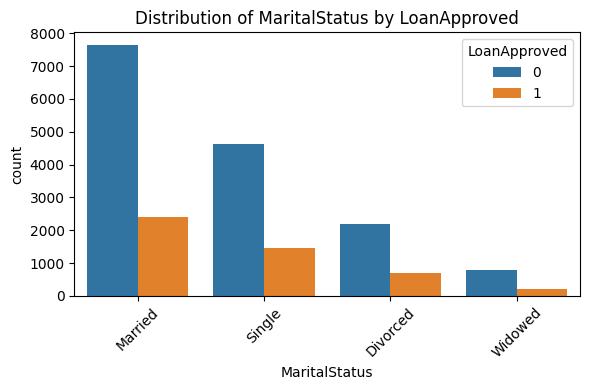

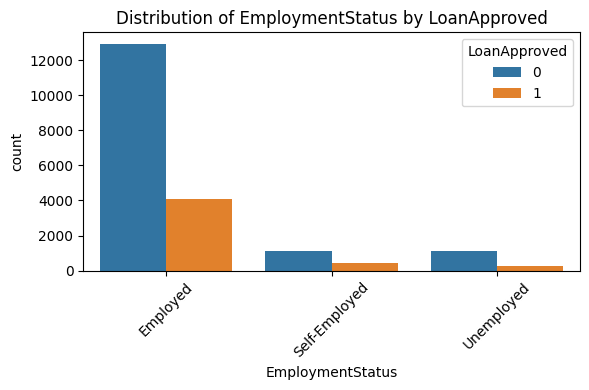

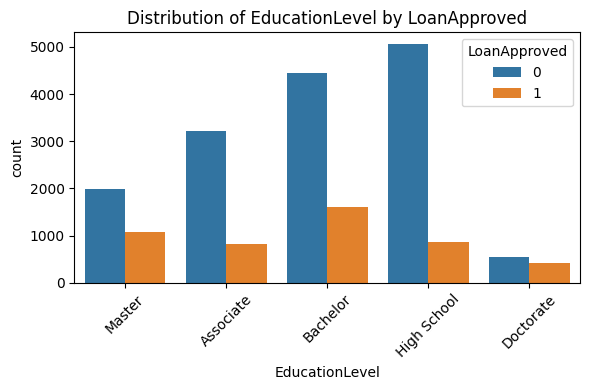

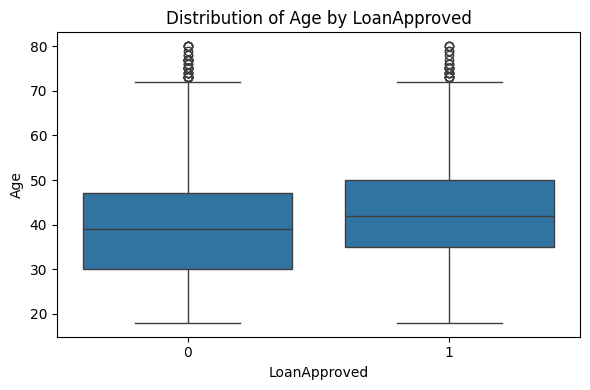

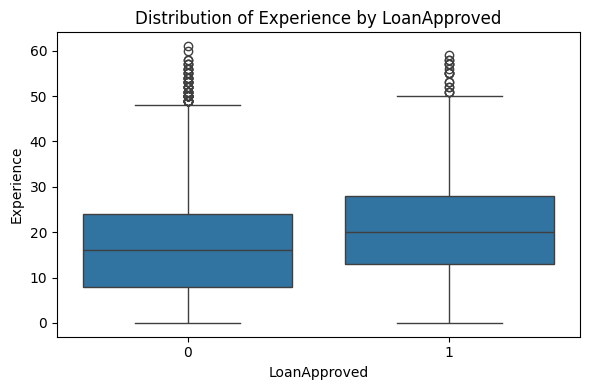

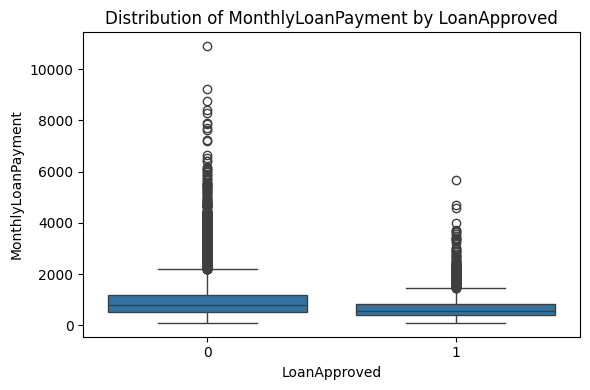

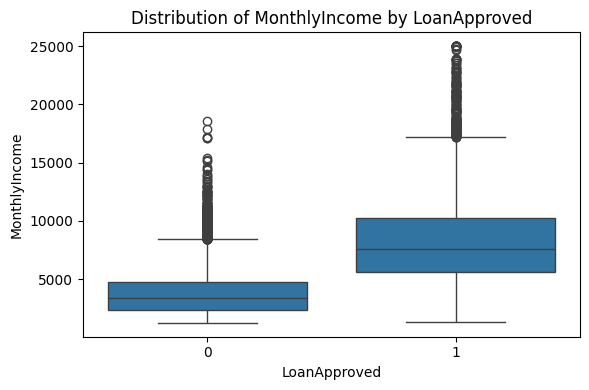

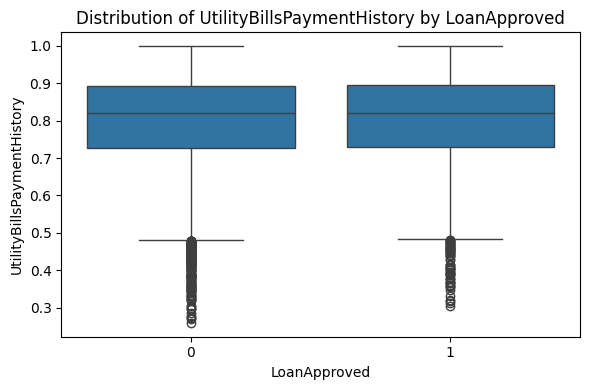

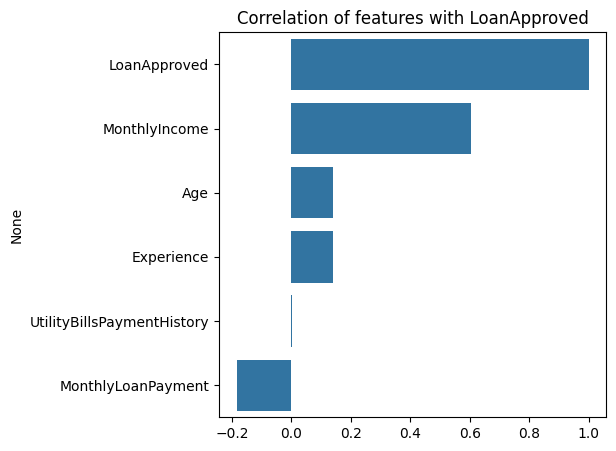

In [34]:
target = "LoanApproved"

# Detect categorical and numerical columns
categorical_cols = df_init_proper.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df_init_proper.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove label col from those lists if present
categorical_cols = [c for c in categorical_cols if c != target]
numerical_cols = [c for c in numerical_cols if c != target]

# --- PLOTS ---

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_init_proper, x=col, hue=target)
    plt.title(f'Distribution of {col} by {target}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_init_proper, x=target, y=col)
    plt.title(f'Distribution of {col} by {target}')
    plt.tight_layout()
    plt.show()

if pd.api.types.is_numeric_dtype(df_init_proper[target]):
    corr = df_init_proper[numerical_cols + [target]].corr()[target].sort_values(ascending=False)
    plt.figure(figsize=(5,5))
    sns.barplot(x=corr.values, y=corr.index)
    plt.title(f'Correlation of features with {target}')
    plt.show()

---

## Biases 

In [35]:
def detect_bias(df, feature, target='LoanApproved'):
    stats = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])
    stats.columns = ['Approved', 'Total', 'Approval_Rate']
    stats['Global_Rate'] = df[target].mean()
    stats['Gap_%'] = (stats['Approval_Rate'] - stats['Global_Rate']) * 100
    
    contingency = pd.crosstab(df[feature], df[target])
    chi2, p_value, _, _ = chi2_contingency(contingency)
    stats['P_Value'] = p_value
    
    return stats.sort_values('Approval_Rate', ascending=False)

In [36]:
def disparate_impact(df, feature, target='LoanApproved'):
    rates = df.groupby(feature)[target].mean()
    max_rate = rates.max()
    
    results = []
    for group in rates.index:
        ratio = rates[group] / max_rate
        results.append({
            'Group': group,
            'Rate': rates[group],
            'Ratio': ratio,
            'Pass_80%': ratio >= 0.8
        })
    
    return pd.DataFrame(results)

In [37]:
df = pd.read_csv("../data/Loan.csv")

age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

print("Bias detection:")
bias_stats = detect_bias(df, 'AgeGroup')
display(bias_stats)

print("\nDisparate impact:")
di_results = disparate_impact(df, 'AgeGroup')
display(di_results)

Bias detection:


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/3152967069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])


,Approved,Total,Approval_Rate,Global_Rate,Gap_%,P_Value
AgeGroup,,,,,,
65+,98,303,0.323432,0.239,8.443234,7.588790e-67
56-65,480,1565,0.306709,0.239,6.770927,7.588790e-67
46-55,1304,4318,0.301992,0.239,6.299166,7.588790e-67
36-45,1653,6470,0.255487,0.239,1.648686,7.588790e-67
26-35,968,4962,0.195083,0.239,-4.391737,7.588790e-67
18-25,192,1579,0.121596,0.239,-11.740405,7.588790e-67



Disparate impact:


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/1801974444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(feature)[target].mean()


,Group,Rate,Ratio,Pass_80%
0,18-25,0.121596,0.375955,False
1,26-35,0.195083,0.603164,False
2,36-45,0.255487,0.789924,False
3,46-55,0.301992,0.933709,True
4,56-65,0.306709,0.948295,True
5,65+,0.323432,1.000000,True


Bias detection:


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/3152967069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])


,Approved,Total,Approval_Rate,Global_Rate,Gap_%,P_Value
AgeGroup,,,,,,
65+,98,303,0.323432,0.239,8.443234,7.588790e-67
56-65,480,1565,0.306709,0.239,6.770927,7.588790e-67
46-55,1304,4318,0.301992,0.239,6.299166,7.588790e-67
36-45,1653,6470,0.255487,0.239,1.648686,7.588790e-67
26-35,968,4962,0.195083,0.239,-4.391737,7.588790e-67
18-25,192,1579,0.121596,0.239,-11.740405,7.588790e-67



Disparate impact:


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/1801974444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(feature)[target].mean()


,Group,Rate,Ratio,Pass_80%
0,18-25,0.121596,0.375955,False
1,26-35,0.195083,0.603164,False
2,36-45,0.255487,0.789924,False
3,46-55,0.301992,0.933709,True
4,56-65,0.306709,0.948295,True
5,65+,0.323432,1.000000,True


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/3526295108.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])
/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/3526295108.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(feature)[target].mean()


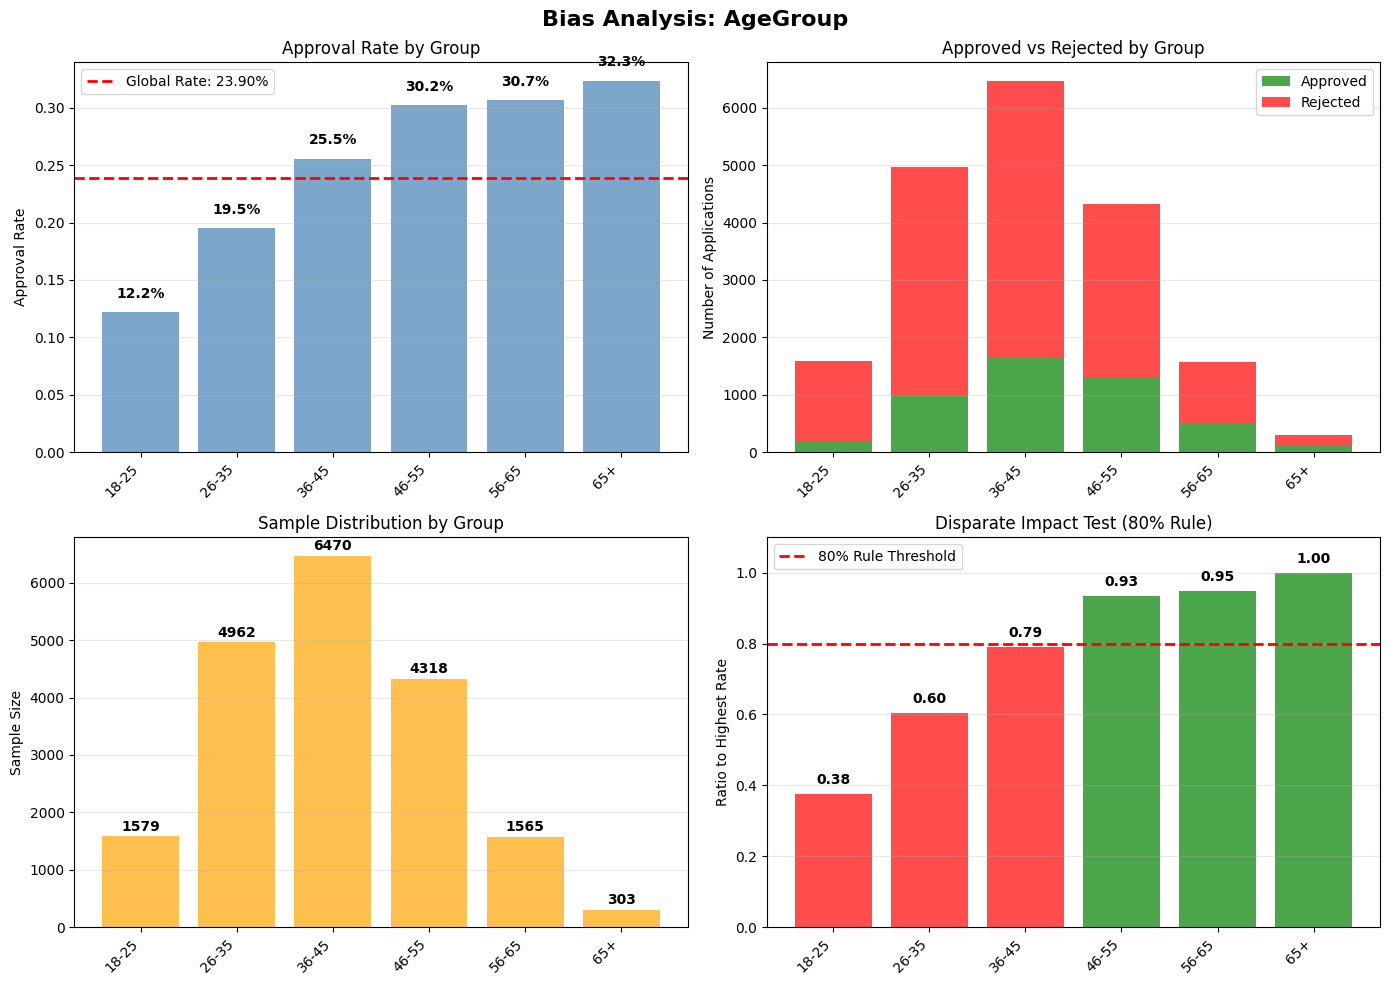


BIAS SUMMARY for AgeGroup
Global Approval Rate: 23.90%
Max Group Rate: 32.34% (65+)
Min Group Rate: 12.16% (18-25)
Difference: 20.18%
Groups failing 80% rule: 3/6



In [38]:
df = pd.read_csv("../data/Loan.csv")

age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 2. Analyse statistique du biais (tableaux)
print("Bias detection:")
bias_stats = detect_bias(df, 'AgeGroup')
display(bias_stats)

print("\nDisparate impact:")
di_results = disparate_impact(df, 'AgeGroup')
display(di_results)

# 3. VISUALISATION GRAPHIQUE DU BIAIS (À AJOUTER ICI)
visualize_bias(df, 'AgeGroup')  # ← Sur les données ORIGINALE

In [39]:
def reweighting(df, target='LoanApproved'):
    df_temp = df.copy()
    df_temp = df_temp.dropna(subset=['Age', target])
    
    age_bins = [18, 25, 35, 45, 55, 65, 100]
    age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df_temp['AgeGroup'] = pd.cut(df_temp['Age'], bins=age_bins, labels=age_labels)
    df_temp = df_temp.dropna(subset=['AgeGroup'])
    
    total = len(df_temp)
    n_groups = df_temp['AgeGroup'].nunique()
    n_labels = df_temp[target].nunique()
    
    weights = []
    for _, row in df_temp.iterrows():
        group = row['AgeGroup']
        label = row[target]
        
        n = len(df_temp[(df_temp['AgeGroup'] == group) & (df_temp[target] == label)])
        expected = total / (n_groups * n_labels)
        weight = expected / n if n > 0 else 1.0
        weights.append(weight)
    
    df_temp['sample_weight'] = weights
    
    print("Reweighting applied")
    print(f"Samples: {len(df_temp)}")
    print(f"Weight range: [{df_temp['sample_weight'].min():.3f}, {df_temp['sample_weight'].max():.3f}]")
    
    return df_temp

df_reweighted = reweighting(df)
display(df_reweighted.groupby('AgeGroup')['sample_weight'].agg(['mean', 'count']))


Reweighting applied
Samples: 19197
Weight range: [0.332, 16.324]


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/1163386260.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_reweighted.groupby('AgeGroup')['sample_weight'].agg(['mean', 'count']))


,mean,count
AgeGroup,,
18-25,2.026282,1579
26-35,0.644800,4962
36-45,0.494513,6470
46-55,0.740968,4318
56-65,2.044409,1565
65+,10.559406,303


In [40]:
def resampling(df, target='LoanApproved', strategy='oversample'):
    df_temp = df.copy()
    df_temp = df_temp.dropna(subset=['Age', target])
    
    age_bins = [18, 25, 35, 45, 55, 65, 100]
    age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df_temp['AgeGroup'] = pd.cut(df_temp['Age'], bins=age_bins, labels=age_labels)
    df_temp = df_temp.dropna(subset=['AgeGroup'])
    
    group_counts = df_temp.groupby(['AgeGroup', target]).size()
    
    if strategy == 'oversample':
        max_count = group_counts.max()
        
        resampled_dfs = []
        for (group, label), count in group_counts.items():
            subset = df_temp[(df_temp['AgeGroup'] == group) & (df_temp[target] == label)]
            n_samples = max_count - count
            if n_samples > 0:
                oversampled = subset.sample(n=n_samples, replace=True, random_state=42)
                resampled_dfs.append(subset)
                resampled_dfs.append(oversampled)
            else:
                resampled_dfs.append(subset)
        
        df_resampled = pd.concat(resampled_dfs, ignore_index=True)
    
    elif strategy == 'undersample':
        min_count = group_counts.min()
        
        resampled_dfs = []
        for (group, label), count in group_counts.items():
            subset = df_temp[(df_temp['AgeGroup'] == group) & (df_temp[target] == label)]
            undersampled = subset.sample(n=min_count, replace=False, random_state=42)
            resampled_dfs.append(undersampled)
        
        df_resampled = pd.concat(resampled_dfs, ignore_index=True)
    
    print(f"Resampling applied: {strategy}")
    print(f"Original samples: {len(df_temp)}")
    print(f"Resampled samples: {len(df_resampled)}")
    
    return df_resampled

df_oversampled = resampling(df, strategy='oversample')
display(df_oversampled.groupby('AgeGroup')[target].value_counts().unstack())

Resampling applied: oversample
Original samples: 19197
Resampled samples: 57804


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/131672484.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_temp.groupby(['AgeGroup', target]).size()
/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/131672484.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_oversampled.groupby('AgeGroup')[target].value_counts().unstack())


LoanApproved,0,1
AgeGroup,,
18-25,4817,4817
26-35,4817,4817
36-45,4817,4817
46-55,4817,4817
56-65,4817,4817
65+,4817,4817


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [42]:
from sklearn.preprocessing import StandardScaler

def fairness_constraints_normalized(df, target='LoanApproved'):
    df_temp = df.copy()
    df_temp = df_temp.dropna(subset=['Age', target])
    
    age_bins = [18, 25, 35, 45, 55, 65, 100]
    age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df_temp['AgeGroup'] = pd.cut(df_temp['Age'], bins=age_bins, labels=age_labels)
    df_temp = df_temp.dropna(subset=['AgeGroup'])
    
    numerical_features = ['AnnualIncome', 'CreditScore', 'DebtToIncomeRatio']
    available_features = [f for f in numerical_features if f in df_temp.columns]
    
    X = df_temp[available_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    y = df_temp[target]
    groups = df_temp['AgeGroup']
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_scaled, y)
    predictions = model.predict(X_scaled)
    
    print("Fairness constraints with normalization")
    print(f"Model accuracy: {accuracy_score(y, predictions):.3f}")
    
    print("\nPrediction rates by age group:")
    results = []
    for group in sorted(groups.unique()):
        mask = groups == group
        pred_rate = predictions[mask].mean()
        actual_rate = y[mask].mean()
        results.append({
            'Group': group,
            'Predicted_Rate': pred_rate,
            'Actual_Rate': actual_rate,
            'Gap': abs(pred_rate - actual_rate)
        })
    
    results_df = pd.DataFrame(results)
    display(results_df)
    
    return model, scaler

model_fair, scaler = fairness_constraints_normalized(df)

Fairness constraints with normalization
Model accuracy: 0.842

Prediction rates by age group:


/Users/brandolini_noe/Desktop/ECE-2025-2026/Ethics-of-AI/ethical_AI_workflow/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/brandolini_noe/Desktop/ECE-2025-2026/Ethics-of-AI/ethical_AI_workflow/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/brandolini_noe/Desktop/ECE-2025-2026/Ethics-of-AI/ethical_AI_workflow/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/brandolini_noe/Desktop/ECE-2025-2026/Ethics-of-AI/ethical_AI_workflow/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brandolini_noe/Desktop/ECE-2025-2026/Ethics-o

,Group,Predicted_Rate,Actual_Rate,Gap
0,18-25,0.105763,0.121596,0.015833
1,26-35,0.132003,0.195083,0.063079
2,36-45,0.161206,0.255487,0.094281
3,46-55,0.214683,0.301992,0.087309
4,56-65,0.247923,0.306709,0.058786
5,65+,0.306931,0.323432,0.016502


In [43]:
def compare_mitigation_results(df, target='LoanApproved'):
   
    print("Bias technique comparison")
   
    
    age_bins = [18, 25, 35, 45, 55, 65, 100]
    age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
    
    print("\n1. Original bias:")
    print("-"*70)
    original = detect_bias(df, 'AgeGroup', target)
    display(original[['Approval_Rate', 'Gap_%']])
    
    di_original = disparate_impact(df, 'AgeGroup', target)
    fails_original = len(di_original[~di_original['Pass_80%']])
    print(f"\nGroups failing 80% rule: {fails_original}/6")
    
    print("\n2. after  REWEIGHTING:")
    print("-"*70)
    df_rw = reweighting(df, target)
    print("Sample weights computed to balance age groups")
    
    print("\n3. after RESAMPLING:")
    print("-"*70)
    df_rs = resampling(df, target, strategy='oversample')
    resampled_stats = detect_bias(df_rs, 'AgeGroup', target)
    display(resampled_stats[['Approval_Rate', 'Gap_%']])
    
    di_resampled = disparate_impact(df_rs, 'AgeGroup', target)
    fails_resampled = len(di_resampled[~di_resampled['Pass_80%']])
    print(f"\nGroups failing 80% rule: {fails_resampled}/6")
    
    print("\n4. FAIRNESS CONSTRAINTS:")
   
    print("Model trained without Age feature")
    print("Uses only: Income, CreditScore, DebtToIncomeRatio")
    
    print("Summary")

    print(f"Original failing groups: {fails_original}/6")
    print(f"After resampling: {fails_resampled}/6")
    print("Fairness constraints: Age feature removed from model")

compare_mitigation_results(df)

Bias technique comparison

1. Original bias:
----------------------------------------------------------------------


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/3152967069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])


,Approval_Rate,Gap_%
AgeGroup,,
65+,0.323432,8.443234
56-65,0.306709,6.770927
46-55,0.301992,6.299166
36-45,0.255487,1.648686
26-35,0.195083,-4.391737
18-25,0.121596,-11.740405



Groups failing 80% rule: 3/6

2. after  REWEIGHTING:
----------------------------------------------------------------------


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/1801974444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(feature)[target].mean()


Reweighting applied
Samples: 19197
Weight range: [0.332, 16.324]
Sample weights computed to balance age groups

3. after RESAMPLING:
----------------------------------------------------------------------
Resampling applied: oversample
Original samples: 19197
Resampled samples: 57804


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/131672484.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_temp.groupby(['AgeGroup', target]).size()
/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/3152967069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])


,Approval_Rate,Gap_%
AgeGroup,,
18-25,0.5,0.0
26-35,0.5,0.0
36-45,0.5,0.0
46-55,0.5,0.0
56-65,0.5,0.0
65+,0.5,0.0



Groups failing 80% rule: 0/6

4. FAIRNESS CONSTRAINTS:
Model trained without Age feature
Uses only: Income, CreditScore, DebtToIncomeRatio
Summary
Original failing groups: 3/6
After resampling: 0/6
Fairness constraints: Age feature removed from model


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/1801974444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(feature)[target].mean()


In [44]:
print("Preparing data with bias mitigation: Resampling")
df_mitigated = resampling(df, target='LoanApproved', strategy='oversample')
print(f"Resampled data ready: {len(df_mitigated)} samples")
print("Age feature kept in dataset")

Preparing data with bias mitigation: Resampling
Resampling applied: oversample
Original samples: 19197
Resampled samples: 57804
Resampled data ready: 57804 samples
Age feature kept in dataset


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/131672484.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_temp.groupby(['AgeGroup', target]).size()


---

## Fine-Tuning

**Importing libraries**

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, roc_curve
import os

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer, set_seed
)

import matplotlib.pyplot as plt

**Configurate the fine-tuning**
* MAX_LEN : Random seed for reproducibility
* EPOCHS : Steps for training operation
* BATCH : Number of samples processed together in one training step
* MODEL : prajjwal1/bert-tiny

*Which method did we choose ?*
* We plan to implement the full fine-tune method because of its good global performance and the small size of our dataset

*Why we decided to use this model?*
* Not heavy
* Possibility of a good trade-off between fine-tuning performance and memory usage

In [46]:
SEED = 42
MODEL_NAME = "prajjwal1/bert-tiny"
MAX_LEN = 96
EPOCHS = 2
BATCH = 16

set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

**Importing Data**

* Dropping useless features to enhance performance  
* Splitting features / target  
* Converting tabular data into textual to be handle by the LLM    

In [47]:
df = df_mitigated.copy()

target = "LoanApproved"

feature_cols = [c for c in df.columns if c != target and c not in ['AgeGroup', 'sample_weight']]

def row_to_text(row, cols):
    parts = []
    for c in cols:
        v = row[c]
        if pd.api.types.is_numeric_dtype(df[c]):
            if isinstance(v, float):
                v = round(v, 3)
            else:
                v = int(v)
        parts.append(f"{c}: {v}")
    return " | ".join(parts)

print(f"Training with resampled data: {len(df)} samples")
print(f"Features: {len(feature_cols)}")
print(f"Age feature: KEPT (bias mitigated via resampling)")

Training with resampled data: 57804 samples
Features: 35
Age feature: KEPT (bias mitigated via resampling)


**Splitting trainings and testing sets**
* Casting the target
* Setting up test_size to 30%

In [48]:
texts = [row_to_text(r, feature_cols) for r in df[feature_cols].to_dict(orient="records")]
y = df[target].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(texts, y, test_size=0.30, random_state=SEED)

print(f"Training set lenght: {len(X_train)}")
print(f"Testing set lenght: {len(X_test)}")

print("Exemple of training data:\n")
print(X_train[0])

Training set lenght: 40462
Testing set lenght: 17342
Exemple of training data:

ApplicationDate: 2061-10-27 | Age: 61 | AnnualIncome: 96669 | CreditScore: 608 | EmploymentStatus: Employed | EducationLevel: Master | Experience: 39 | LoanAmount: 18773 | LoanDuration: 60 | MaritalStatus: Single | NumberOfDependents: 1 | HomeOwnershipStatus: Mortgage | MonthlyDebtPayments: 833 | CreditCardUtilizationRate: 0.155 | NumberOfOpenCreditLines: 5 | NumberOfCreditInquiries: 3 | DebtToIncomeRatio: 0.072 | BankruptcyHistory: 0 | LoanPurpose: Other | PreviousLoanDefaults: 0 | PaymentHistory: 13 | LengthOfCreditHistory: 4 | SavingsAccountBalance: 8455 | CheckingAccountBalance: 309 | TotalAssets: 150569 | TotalLiabilities: 54823 | MonthlyIncome: 8055.75 | UtilityBillsPaymentHistory: 0.868 | JobTenure: 3 | NetWorth: 95746 | BaseInterestRate: 0.22 | InterestRate: 0.19 | MonthlyLoanPayment: 486.486 | TotalDebtToIncomeRatio: 0.164 | RiskScore: 36.8


**Tokenizing and Building Hugging Face Datasets**

* Load the tokenizer linked to the chosen pretrained model   
* Provide a more-readable format for tensors across the encode batch function   
* Create Hugging Face Dataset    
* Padding each batch to the longest sequence in it with the collator (avoir to fix max_lenght and then enhance performance)

In [49]:
path_to_model = "loan_model/"

if os.path.exists(path_to_model) :
    print("A tockenizer already exist")
    tok = AutoTokenizer.from_pretrained(path_to_model)
else :
    print("No tockenizer identify")
    tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

A tockenizer already exist


In [50]:
def encode_batch(batch):
    """
    Function that converts text and labels into model-readable tensors
    """
    enc = tok(batch["text"], truncation=True, padding=False, max_length=MAX_LEN)
    enc['labels'] = batch['labels']
    return enc

# Build the Hugging Face Datasets
ds_train = Dataset.from_dict({"text": X_train, "labels": y_train}).map(encode_batch, batched=True)
ds_test  = Dataset.from_dict({"text": X_test,  "labels": y_test}).map(encode_batch, batched=True)

# Data collator handles dynamic padding per batch
collator = DataCollatorWithPadding(tokenizer=tok)

Map: 100%|██████████| 17342/17342 [00:01<00:00, 11186.86 examples/s]


**Fine-tuning step**
* Setting up the model, training arguments and the trainer
* Launching the training

**NB : this step will cost you 3 minutes of your life :)**

In [51]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer


if os.path.exists(path_to_model) :
    print("A model already exist")
    model = AutoModelForSequenceClassification.from_pretrained(path_to_model)
else :
    print("No model already train.")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2) 

A model already exist


In [52]:
import accelerate
print(accelerate.__version__)

1.10.1


In [53]:
# Only for train the model again

args = TrainingArguments(
    output_dir="outputs",
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH,
    num_train_epochs=EPOCHS,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    data_collator=collator,
    tokenizer=tok,
)

trainer.train()

/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_16472/3769685250.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/brandolini_noe/Desktop/ECE-2025-2026/Ethics-of-AI/ethical_AI_workflow/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
500,0.455900
1000,0.442400
1500,0.441700
2000,0.438700
2500,0.423000
3000,0.416200
3500,0.425700
4000,0.420000
4500,0.418500
5000,0.419800


TrainOutput(global_step=5058, training_loss=0.43033631190145, metrics={'train_runtime': 71.4292, 'train_samples_per_second': 1132.926, 'train_steps_per_second': 70.811, 'total_flos': 19277417479680.0, 'train_loss': 0.43033631190145, 'epoch': 2.0})

**Applying the fine-tuned model**
* Applying AUC Score and F1-Score to evaluate the model
* Plotting the AUC Score for more visibility

In [54]:
def plot_roc_auc(y_true, y_prob, title_prefix="Test"):
    """
    y_true: 1D array-like of true labels (0/1)
    y_prob: 1D array-like of predicted probabilities for class 1
    """
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC Curve")
    plt.legend(loc="lower right")
    plt.show()
    return auc

In [55]:
preds = trainer.predict(ds_test)
logits = preds.predictions
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.9115996947151602


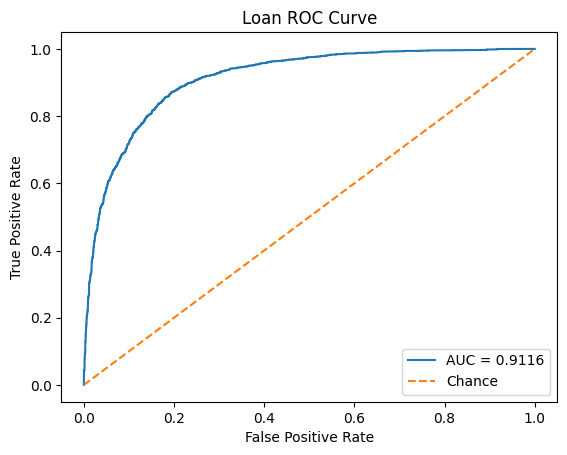

ROC-AUC: 0.9115996947151602


In [56]:
auc = plot_roc_auc(y_test, probs, title_prefix="Loan")
print("ROC-AUC:", auc)

**Saving the model**

In [57]:
# Save the model weights and configuration
model.save_pretrained("loan_model")

# Save the tokenizer (you need it to encode text again later)
tok.save_pretrained("loan_model")

print("Model and tokenizer saved in folder 'loan_model/'")


Model and tokenizer saved in folder 'loan_model/'


**Conclusion**

* The model can easily distinguish between people who can and cannot get a loan due to predictive power from the features
* It also successfully adapted from the original tabular format. Then we can say full fine-tuning worked well
* AUC score reveals that the ranking of positives vs negatives is almost perfect

This model could be optimized by :
* Adding some features we removed to better understand causality of a loan not given
* Adding more epochs
* Trying to get a bigger dataset and apply other methods (LoRa, Distillation)

---

## xAI